# KG Path Reasoning Analysis
Analysis of `reasoning_analysis.json` — covers path coverage, path length distribution, score distributions, mention extraction validation, and qualitative examples.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────
RESULTS_PATH = './results/reasoning_analysis.json'

with open(RESULTS_PATH) as f:
    data = json.load(f)

stats   = data['statistics']
results = data['all_results']
df      = pd.DataFrame(results)

print(f'Loaded {len(df):,} samples')
print(f'Columns: {list(df.columns)}')

Loaded 22,123 samples
Columns: ['sample_idx', 'dialogue', 'ground_truth_id', 'ground_truth_name', 'top_1_prediction', 'top_1_prediction_name', 'top_10_predictions', 'top_50_predictions', 'is_correct_top_1', 'is_correct_top_10', 'is_correct_top_50', 'path_found', 'path_note', 'mentioned_movies', 'top_5_predicted_names', 'explanation_path', 'scoring_method']


## 1. Summary Statistics

In [3]:
# ── Core coverage metrics ──────────────────────────────────────────────────
total          = len(df)
paths_found    = df['path_found'].sum()
path_coverage  = paths_found / total * 100

correct_top1   = df['is_correct_top_1'].sum()
correct_top10  = df['is_correct_top_10'].sum()
correct_top50  = df['is_correct_top_50'].sum()

# PC@5 — path found AND correct in top-5
df['is_correct_top_5'] = df['top_10_predictions'].apply(
    lambda preds: df.loc[df['top_10_predictions'].apply(lambda x: x == preds).idxmax(), 'ground_truth_id']
    if False else None
)
# Correct way — check if ground truth is in top-5
df['is_correct_top_5'] = df.apply(
    lambda r: r['ground_truth_id'] in r['top_10_predictions'][:5], axis=1
)
correct_top5   = df['is_correct_top_5'].sum()
pc5_num        = df[df['is_correct_top_5'] & df['path_found']].shape[0]
pc5            = pc5_num / max(correct_top5, 1) * 100

avg_mentioned  = df['mentioned_movies'].apply(len).mean()

print('=' * 50)
print('SUMMARY STATISTICS')
print('=' * 50)
print(f'Total samples:                {total:>10,}')
print(f'Paths found:                  {paths_found:>10,}')
print(f'Path Coverage (PC):           {path_coverage:>10.2f}%')
print(f'Path Coverage on Correct@5:   {pc5:>10.2f}%')
print(f'Avg mentioned movies/sample:  {avg_mentioned:>10.2f}')


SUMMARY STATISTICS
Total samples:                    22,123
Paths found:                      16,227
Path Coverage (PC):                73.35%
Path Coverage on Correct@5:        80.35%
Avg mentioned movies/sample:        3.01


## 2. Path Coverage Breakdown

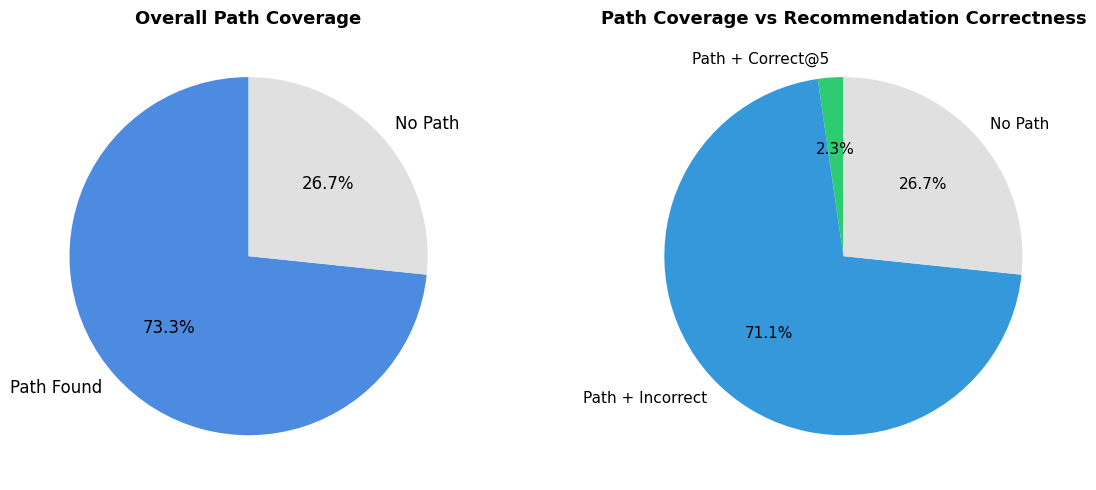

In [4]:
# ── Path coverage breakdown pie chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overall path found vs not found
labels1 = ['Path Found', 'No Path']
sizes1  = [paths_found, total - paths_found]
colors1 = ['#4C8BE0', '#E0E0E0']
axes[0].pie(sizes1, labels=labels1, autopct='%1.1f%%', colors=colors1,
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Path Coverage', fontsize=13, fontweight='bold')

# Right: breakdown of path found samples by correctness
path_and_correct5  = df[df['path_found'] & df['is_correct_top_5']].shape[0]
path_not_correct5  = df[df['path_found'] & ~df['is_correct_top_5']].shape[0]
no_path            = total - paths_found

labels2 = ['Path + Correct@5', 'Path + Incorrect', 'No Path']
sizes2  = [path_and_correct5, path_not_correct5, no_path]
colors2 = ['#2ECC71', '#3498DB', '#E0E0E0']
axes[1].pie(sizes2, labels=labels2, autopct='%1.1f%%', colors=colors2,
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Path Coverage vs Recommendation Correctness', fontsize=13, fontweight='bold')

plt.tight_layout()
#plt.savefig('./results/path_coverage_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: ./results/path_coverage_breakdown.png')

## 3. Path Length Distribution

Path length distribution (number of nodes):
  2 nodes (direct (no intermediate)): 4,067 (25.1%)
  3 nodes (2-hop (with intermediate)): 12,160 (74.9%)


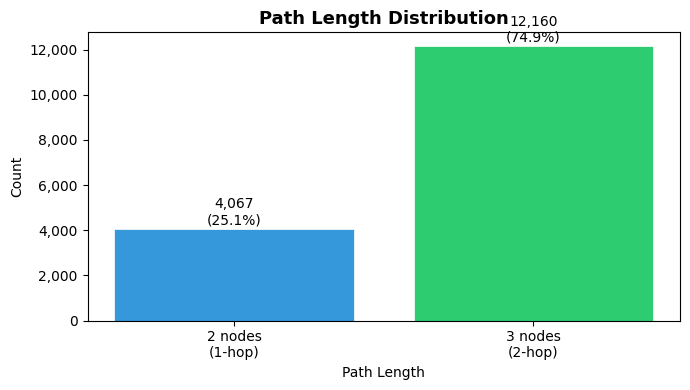

In [5]:
# ── Path length distribution ───────────────────────────────────────────────
path_lengths = df[df['path_found']]['explanation_path'].apply(
    lambda ep: len(ep['path']) if isinstance(ep, dict) else 0
)

length_counts = path_lengths.value_counts().sort_index()
print('Path length distribution (number of nodes):')
for length, count in length_counts.items():
    hops = length - 1
    pct  = count / paths_found * 100
    label = 'direct (no intermediate)' if hops == 1 else f'{hops}-hop (with intermediate)'
    print(f'  {length} nodes ({label}): {count:,} ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'{l} nodes\n({l-1}-hop)' for l in length_counts.index],
              length_counts.values,
              color=['#3498DB', '#2ECC71', '#E74C3C'][:len(length_counts)],
              edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, length_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({count/paths_found*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Path Length Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Path Length')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
#plt.savefig('./results/path_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: ./results/path_length_distribution.png')

## 4. Path Score Distribution

Path score stats:
  Mean:   0.4613
  Median: 0.4414
  Std:    0.0796
  Min:    0.3030
  Max:    0.7225


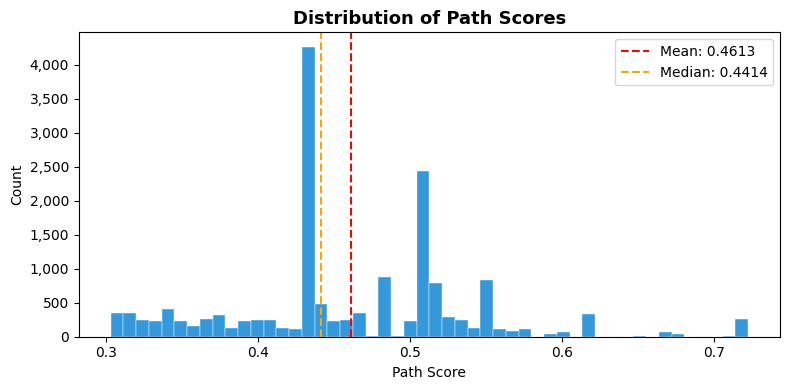

In [6]:
# ── Path score distribution ────────────────────────────────────────────────
path_scores = df[df['path_found']]['explanation_path'].apply(
    lambda ep: ep['score'] if isinstance(ep, dict) else None
).dropna()

print(f'Path score stats:')
print(f'  Mean:   {path_scores.mean():.4f}')
print(f'  Median: {path_scores.median():.4f}')
print(f'  Std:    {path_scores.std():.4f}')
print(f'  Min:    {path_scores.min():.4f}')
print(f'  Max:    {path_scores.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(path_scores, bins=50, color='#3498DB', edgecolor='white', linewidth=0.3)
ax.axvline(path_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {path_scores.mean():.4f}')
ax.axvline(path_scores.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {path_scores.median():.4f}')
ax.set_title('Distribution of Path Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('Path Score')
ax.set_ylabel('Count')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
#plt.savefig('./results/path_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: ./results/path_score_distribution.png')

## 5. Mentioned Movies per Sample

Mentioned movies per sample:
  Mean:   3.01
  Median: 3
  Max:    14

  0 mentions: 5,062 samples (22.9%)
  1 mentions: 2,163 samples (9.8%)
  2 mentions: 2,778 samples (12.6%)
  3 mentions: 2,873 samples (13.0%)
  4 mentions: 3,136 samples (14.2%)
  5 mentions: 2,592 samples (11.7%)
  6 mentions: 1,680 samples (7.6%)
  7 mentions: 958 samples (4.3%)
  8 mentions: 426 samples (1.9%)
  9 mentions: 223 samples (1.0%)
  10 mentions: 118 samples (0.5%)
  11 mentions: 66 samples (0.3%)
  12 mentions: 30 samples (0.1%)
  13 mentions: 10 samples (0.0%)
  14 mentions: 8 samples (0.0%)


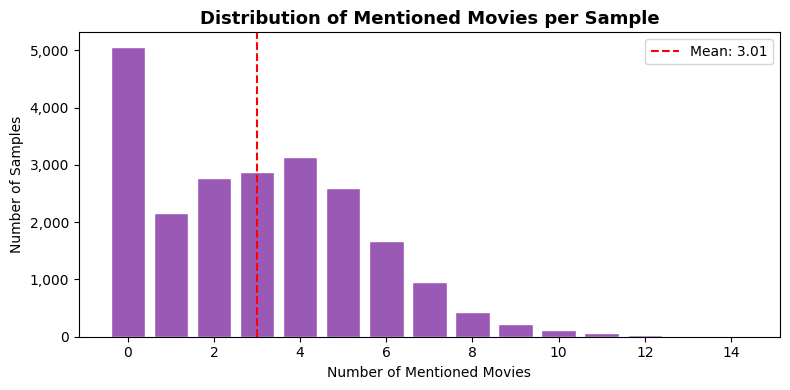

In [7]:
# ── Mentioned movies per sample ────────────────────────────────────────────
mention_counts = df['mentioned_movies'].apply(len)

print(f'Mentioned movies per sample:')
print(f'  Mean:   {mention_counts.mean():.2f}')
print(f'  Median: {mention_counts.median():.0f}')
print(f'  Max:    {mention_counts.max()}')
print()
dist = mention_counts.value_counts().sort_index()
for n, count in dist.items():
    print(f'  {n} mentions: {count:,} samples ({count/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color='#9B59B6', edgecolor='white')
ax.set_title('Distribution of Mentioned Movies per Sample', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Mentioned Movies')
ax.set_ylabel('Number of Samples')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axvline(mention_counts.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {mention_counts.mean():.2f}')
ax.legend()
plt.tight_layout()
#plt.savefig('./results/mention_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: ./results/mention_distribution.png')

## 6. Most Common Intermediate Nodes

Total 2-hop paths: 12,160
Unique intermediates: 128

Top 20 intermediate nodes:
  comedy                                    4,462  (36.7%)
  thriller                                  1,090  (9.0%)
  superhero                                 1,052  (8.7%)
  horror                                      856  (7.0%)
  action                                      805  (6.6%)
  drama                                       464  (3.8%)
  animated                                    315  (2.6%)
  sci-fi                                      281  (2.3%)
  brad pitt                                   254  (2.1%)
  fantasy                                     215  (1.8%)
  quentin tarantino                           202  (1.7%)
  mystery                                     154  (1.3%)
  jeremy renner                               128  (1.1%)
  melissa mccarthy                            104  (0.9%)
  bill murray                                 103  (0.8%)
  musical                                      96

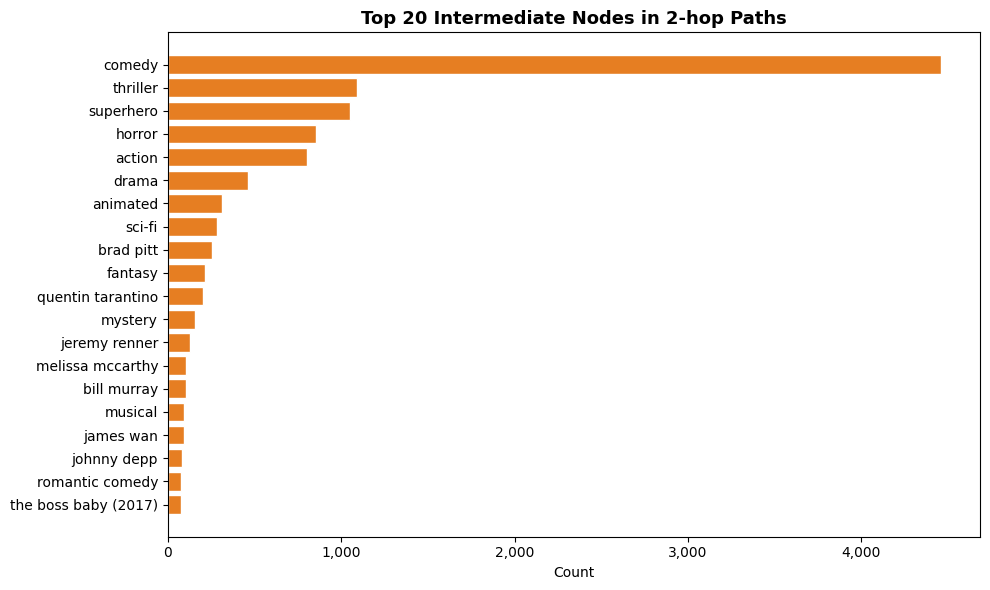

In [8]:
# ── Most common intermediate nodes in 2-hop paths ─────────────────────────
intermediates = []
for r in results:
    if r['path_found']:
        path = r['explanation_path'].get('path', [])
        if len(path) == 3:  # 2-hop: source -> intermediate -> target
            intermediates.append(path[1])

inter_counts = Counter(intermediates)
top_intermediates = inter_counts.most_common(20)

print(f'Total 2-hop paths: {len(intermediates):,}')
print(f'Unique intermediates: {len(inter_counts):,}')
print()
print('Top 20 intermediate nodes:')
for name, count in top_intermediates:
    print(f'  {name:<40} {count:>6,}  ({count/len(intermediates)*100:.1f}%)')

if top_intermediates:
    names, counts = zip(*top_intermediates)
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(names))
    ax.barh(y_pos, counts, color='#E67E22', edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=10)
    ax.invert_yaxis()
    ax.set_title('Top 20 Intermediate Nodes in 2-hop Paths', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    #plt.savefig('./results/top_intermediates.png', dpi=150, bbox_inches='tight')
    plt.show()
    #print('Saved: ./results/top_intermediates.png')
else:
    print('No 2-hop paths found in this sample.')

## 7. Path Coverage by Recommendation Correctness

In [9]:
# ── PC@k for different k values ────────────────────────────────────────────
def compute_pc_at_k(df, k):
    correct_at_k = df.apply(
        lambda r: r['ground_truth_id'] in r['top_10_predictions'][:k]
        if k <= 10 else r['ground_truth_id'] in r['top_50_predictions'][:k],
        axis=1
    )
    n_correct = correct_at_k.sum()
    n_path_and_correct = (correct_at_k & df['path_found']).sum()
    pc = n_path_and_correct / max(n_correct, 1) * 100
    return n_correct, n_path_and_correct, pc

print('Path Coverage at different k values:')
print(f'{"k":>4}  {"Correct@k":>12}  {"Path+Correct":>14}  {"PC@k":>8}')
print('-' * 45)
for k in [1, 5, 10, 50]:
    n_c, n_pc, pc = compute_pc_at_k(df, k)
    print(f'{k:>4}  {n_c:>12,}  {n_pc:>14,}  {pc:>7.2f}%')

print(f'\nOverall PC (all samples): {path_coverage:.2f}%')

Path Coverage at different k values:
   k     Correct@k    Path+Correct      PC@k
---------------------------------------------
   1           157             132    84.08%
   5           631             507    80.35%
  10         1,092             853    78.11%
  50         2,750           1,965    71.45%

Overall PC (all samples): 73.35%


## 8. Scoring Method Distribution

In [10]:
# ── Scoring method breakdown ───────────────────────────────────────────────
method_counts = df['scoring_method'].value_counts()
print('Scoring method distribution:')
for method, count in method_counts.items():
    print(f'  {method:<20} {count:>8,}  ({count/total*100:.1f}%)')

Scoring method distribution:
  embedding              16,227  (73.3%)
  none                    5,896  (26.7%)


## 9. Qualitative Path Examples

In [11]:
# ── Qualitative examples ───────────────────────────────────────────────────
# Show high-scoring paths, split by 1-hop and 2-hop

path_rows = df[df['path_found']].copy()
path_rows['path_list']    = path_rows['explanation_path'].apply(lambda ep: ep['path'])
path_rows['path_score']   = path_rows['explanation_path'].apply(lambda ep: ep['score'])
path_rows['path_length_nodes'] = path_rows['path_list'].apply(len)

print('=' * 70)
print('TOP 5 HIGH-SCORING 2-HOP PATHS (source → intermediate → target)')
print('=' * 70)
two_hop = path_rows[path_rows['path_length_nodes'] == 3].nlargest(5, 'path_score')
for _, row in two_hop.iterrows():
    path = row['path_list']
    print(f"  {path[0]} → [{path[1]}] → {path[2]}")
    print(f"  Score: {row['path_score']:.4f} | Correct@10: {row['is_correct_top_10']}")
    print(f"  Dialogue: {row['dialogue'][:80]}...")
    print()

print('=' * 70)
print('TOP 5 HIGH-SCORING 1-HOP PATHS (direct connection)')
print('=' * 70)
one_hop = path_rows[path_rows['path_length_nodes'] == 2].nlargest(5, 'path_score')
for _, row in one_hop.iterrows():
    path = row['path_list']
    print(f"  {path[0]} → {path[1]} (direct)")
    print(f"  Score: {row['path_score']:.4f} | Correct@10: {row['is_correct_top_10']}")
    print(f"  Dialogue: {row['dialogue'][:80]}...")
    print()

TOP 5 HIGH-SCORING 2-HOP PATHS (source → intermediate → target)
  runaway bride (1999) → [julia roberts] → love stinks (1999)
  Score: 0.6677 | Correct@10: False
  Dialogue: System: Aloha!User: Hi there! How are you?System: How are you?!User: Im good!Sys...

  runaway bride (1999) → [julia roberts] → love stinks (1999)
  Score: 0.6677 | Correct@10: False
  Dialogue: System: Aloha!User: Hi there! How are you?System: How are you?!User: Im good!Sys...

  runaway bride (1999) → [julia roberts] → love stinks (1999)
  Score: 0.6677 | Correct@10: False
  Dialogue: System: Aloha!User: Hi there! How are you?System: How are you?!User: Im good!Sys...

  runaway bride (1999) → [julia roberts] → love stinks (1999)
  Score: 0.6677 | Correct@10: False
  Dialogue: System: Aloha!User: Hi there! How are you?System: How are you?!User: Im good!Sys...

  runaway bride (1999) → [julia roberts] → love stinks (1999)
  Score: 0.6677 | Correct@10: False
  Dialogue: System: Aloha!User: Hi there! How are you?Syst

## 10. Export Summary Table

In [13]:
# ── Export clean summary table for report ─────────────────────────────────
_, _, pc5_val = compute_pc_at_k(df, 5)

summary = pd.DataFrame([
    {'Metric': 'Total test samples',                  'Value': f'{total:,}'},
    {'Metric': 'Paths found',                         'Value': f'{paths_found:,}'},
    {'Metric': 'Path Coverage (PC)',                  'Value': f'{path_coverage:.2f}%'},
    {'Metric': 'Path Coverage on Correct@5 (PC@5)',   'Value': f'{pc5_val:.2f}%'},
    {'Metric': 'Avg mentioned movies per sample',     'Value': f'{avg_mentioned:.2f}'},
])

print(summary.to_string(index=False))
#summary.to_csv('./results/reasoning_summary.csv', index=False)
#print('\nSaved: ./results/reasoning_summary.csv')

                           Metric  Value
               Total test samples 22,123
                      Paths found 16,227
               Path Coverage (PC) 73.35%
Path Coverage on Correct@5 (PC@5) 80.35%
  Avg mentioned movies per sample   3.01
